In [1]:
import sys
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib import pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report
)

sys.path.append(os.path.abspath("../src"))

from models import ResNet18

from data import (
    prepare_full_dataframe, 
    prepare_data, 
    create_binary_target,
    sample_image_path,
    get_transforms
)

from train_eval import (
    setup_training,
    train_model,
    evaluate,
    predict_single_image
)

from utils import (
    get_device,
    plot_training_history,
    plot_confusion_matrix_figure,
    get_model_path
)
import config

/Users/tommy_tran/cxr-ai/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Preprocessing

## Data Exploration

In [2]:
dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")

# Prepare the full dataframe with all necessary columns
# - Loads dataframe from csv
# - Creates new column "image_path" for image root directory + image filename
# - Creates binary target variable "target" where 0 = "No Finding" and 1 = any other finding
# - Creates column to split the data into train/val/test based on the "Patient ID" column
df = prepare_full_dataframe(metadata_file, dataset_path)

print(df.head())
print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Un

In [3]:
# Analyze the distribution of findings
df["Finding Labels"].value_counts().head()

Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [4]:
# Analyze the distribution of the binary target variable
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [5]:
# Analyze target proportions
_, target_proportions = create_binary_target(df)
print("Target proportions:", target_proportions)

Target proportions: target
0    0.538361
1    0.461639
Name: proportion, dtype: float64


In [6]:
missing = df["image_path"].isna().sum()
print(f"Missing images:", missing)

Missing images: 0


## Create Data Loaders

In [7]:
# Prepare the data loaders
train_loader, val_loader, test_loader = prepare_data(df)

## Sanity Check

In [8]:
# Check the shapes of the batches on one batch
# images, labels = next(iter(train_loader))
# print("Image batch shape:", images.shape)
# print("Label batch shape:", labels.shape)
# print("Unique labels:", labels.unique())

# ResNet18

## Initialize Model

In [9]:
device = get_device()

model = ResNet18(num_classes=2, in_channels=1, pretrained=True).to(device)
# Uses pretrained weights

criterion, optimizer = setup_training(model)

Using MPS (GPU)


## Training the Model

In [10]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "resnet18_binary_target", 3)

Epoch 1/10 | ETA: 04:34:54 | Total ETA: 05:05:27
  Train Loss: 0.6139 | Train Acc: 0.6733
  Val Loss: 0.5995 | Val Acc: 0.6949
  Val Precision: 0.6868
  Val Recall: 0.6084 | Val F1: 0.6452
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/resnet18_binary_target.pt
------------------------------------------------------------


Epoch 2/10 | ETA: 04:04:25 | Total ETA: 05:05:27
  Train Loss: 0.5883 | Train Acc: 0.6983
  Val Loss: 0.5901 | Val Acc: 0.6966
  Val Precision: 0.6792
  Val Recall: 0.6346 | Val F1: 0.6561
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/resnet18_binary_target.pt
------------------------------------------------------------


Epoch 3/10 | ETA: 03:31:33 | Total ETA: 05:05:27
  Train Loss: 0.5765 | Train Acc: 0.7091
  Val Loss: 0.6069 | Val Acc: 0.6963
  Val Precision: 0.6805
  Val Recall: 0.6301 | Val F1: 0.6543
------------------------------------------------------------
No improvement. Patience: 1/3
------------------------------------------------------------


Epoch 4/10 | ETA: 02:59:41 | Total ETA: 05:05:27
  Train Loss: 0.5642 | Train Acc: 0.7177
  Val Loss: 0.5922 | Val Acc: 0.6980
  Val Precision: 0.6609
  Val Recall: 0.6937 | Val F1: 0.6769
------------------------------------------------------------
Saved best model to /Users/tommy_tran/cxr-ai/saved_models/resnet18_binary_target.pt
------------------------------------------------------------


Epoch 5/10 | ETA: 02:28:38 | Total ETA: 05:05:27
  Train Loss: 0.5495 | Train Acc: 0.7270
  Val Loss: 0.5945 | Val Acc: 0.7010
  Val Precision: 0.6832
  Val Recall: 0.6423 | Val F1: 0.6621
------------------------------------------------------------
No improvement. Patience: 1/3
------------------------------------------------------------


Epoch 6/10 | ETA: 01:57:56 | Total ETA: 05:05:27
  Train Loss: 0.5275 | Train Acc: 0.7419
  Val Loss: 0.6133 | Val Acc: 0.6941
  Val Precision: 0.6668
  Val Recall: 0.6585 | Val F1: 0.6626
------------------------------------------------------------
No improvement. Patience: 2/3
------------------------------------------------------------


Epoch 7/10 | ETA: 01:27:53 | Total ETA: 05:05:27
  Train Loss: 0.4945 | Train Acc: 0.7619
  Val Loss: 0.6331 | Val Acc: 0.6776
  Val Precision: 0.6486
  Val Recall: 0.6396 | Val F1: 0.6440
------------------------------------------------------------
No improvement. Patience: 3/3
------------------------------------------------------------
Early stopping at epoch 7 (patience 3 exceeded)


## Analyze Training History

In [17]:
plot_training_history(history)

NameError: name 'history' is not defined

# Best Model Testing

In [11]:
save_path = get_model_path("resnet18_binary_target")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = ResNet18(num_classes=2, in_channels=1).to(device)
best_model.load_state_dict(torch.load(save_path))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/resnet18_binary_target.pt


Val: 100%|██████████| 255/255 [04:12<00:00,  1.01it/s, avg_acc=0.7035, avg_loss=0.5843]


Test Results
  Loss: 0.5843
  Accuracy: 0.7035
  Precision: 0.6674
  Recall: 0.7142
  F1 Score: 0.6900


## Evaluating Test Results

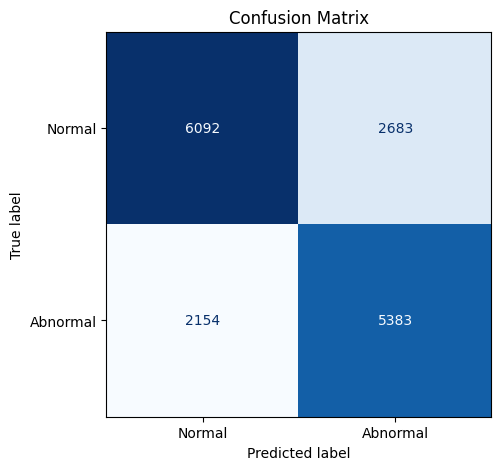

In [12]:
plot_confusion_matrix_figure(test_labels, test_preds, ["Normal", "Abnormal"])

# Making Prediction

In [25]:
import random

image_path = sample_image_path(df, split="test", seed=random.randint(0, 2**32 - 1))
_, eval_transforms = get_transforms()  # Get the evaluation transforms (no augmentation)

result = predict_single_image(image_path, best_model, device, eval_transforms, df=df)

print("Image path:", image_path)
print("Predicted class:", result["predicted_class"])
print("True label:", result["true_label"])
print("Probabilities:", result["probabilities"])


Image path: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays/images_010/images/00022170_007.png
Predicted class: normal
True label: normal
Probabilities: {'normal': 0.6627849340438843, 'abnormal': 0.33721503615379333}
